In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os
from PIL import Image

from myDataset import *

# imports loss, accuracy and confusion matrix plots
from MetricMethods import *

# imports train, test methods
from ArchitectureMethods import *



seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.empty_cache()

# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/Custom All
/user/HS401/ob00564/Documents/COM3001
cuda


In [2]:
# Dataset Creation
train_dataset = myDataset(directory = "Custom All/DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "Custom All/DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "Custom All/DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

# DataLoader Creation
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)



Train set length: 3241
Test set length: 404
Validation set length: 408


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ArchitectureThree(nn.Module):
    
    def __init__(self):
        super(ArchitectureThree, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)  

        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.batch_norm3 = nn.BatchNorm2d(128)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28 * 128, 128)
        self.fc2 = nn.Linear(128, 7)

        self.dropout1 = nn.Dropout(p=0.4)
        self.dropout2 = nn.Dropout(p=0.4)
        self.dropout3 = nn.Dropout(p=0.4)

    def forward(self, x):

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)
        # Output = 112 x 112 x 32

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)
         # Output = 56 x 56 x 64

        x = self.conv3(x)
        x = self.batch_norm3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout3(x)
         # Output = 28 x 28 x 128

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x


100%|██████████| 203/203 [00:08<00:00, 23.94it/s]


Adam
Epoch 1/50, Training Loss: 2.4778, Validation Loss: 1.4940
Epoch 1/50, Training Acc: 37.027914614121514, Validation Accuracy: 48.55769230769231
SGD
Epoch 1/50, Training Loss: 3.0263, Validation Loss: 1.7008
Epoch 1/50, Training Acc: 27.733305966064588, Validation Accuracy: 30.528846153846157


100%|██████████| 203/203 [00:08<00:00, 24.50it/s]


Adam
Epoch 2/50, Training Loss: 1.7471, Validation Loss: 1.4794
Epoch 2/50, Training Acc: 49.08661740558292, Validation Accuracy: 49.03846153846153
SGD
Epoch 2/50, Training Loss: 1.4788, Validation Loss: 1.4045
Epoch 2/50, Training Acc: 44.01340996168583, Validation Accuracy: 44.95192307692308


100%|██████████| 203/203 [00:08<00:00, 24.48it/s]


...

Adam
Epoch 48/50, Training Loss: 0.6032, Validation Loss: 0.6773
Epoch 48/50, Training Acc: 83.25807334428023, Validation Accuracy: 78.60576923076923
SGD
Epoch 48/50, Training Loss: 0.1979, Validation Loss: 0.4436
Epoch 48/50, Training Acc: 94.04077723043241, Validation Accuracy: 83.41346153846155


100%|██████████| 203/203 [00:08<00:00, 24.04it/s]


Adam
Epoch 49/50, Training Loss: 0.6017, Validation Loss: 0.6661
Epoch 49/50, Training Acc: 83.40517241379311, Validation Accuracy: 78.125
SGD
Epoch 49/50, Training Loss: 0.1751, Validation Loss: 0.4408
Epoch 49/50, Training Acc: 95.04310344827587, Validation Accuracy: 84.13461538461539


100%|██████████| 203/203 [00:08<00:00, 24.05it/s]


Adam
Epoch 50/50, Training Loss: 0.6011, Validation Loss: 0.6664
Epoch 50/50, Training Acc: 83.6035851122058, Validation Accuracy: 79.8076923076923
SGD
Epoch 50/50, Training Loss: 0.1763, Validation Loss: 0.4388
Epoch 50/50, Training Acc: 94.79679802955665, Validation Accuracy: 83.89423076923077
Models saved successfully!
Test Adam Loss: 0.6866, Test Adam Accuracy: 77.45%
Test SGD Loss: 0.6454, Test SGD Accuracy: 79.66%


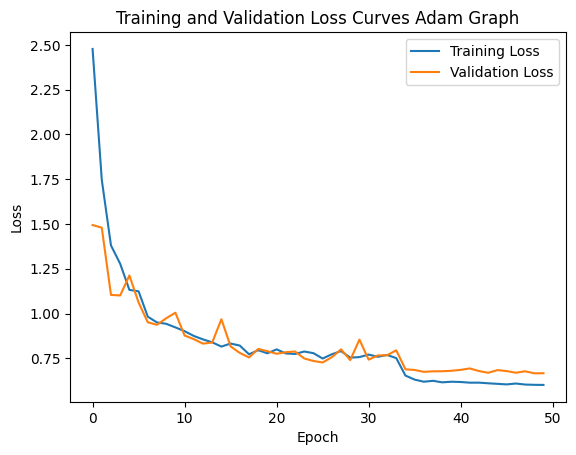

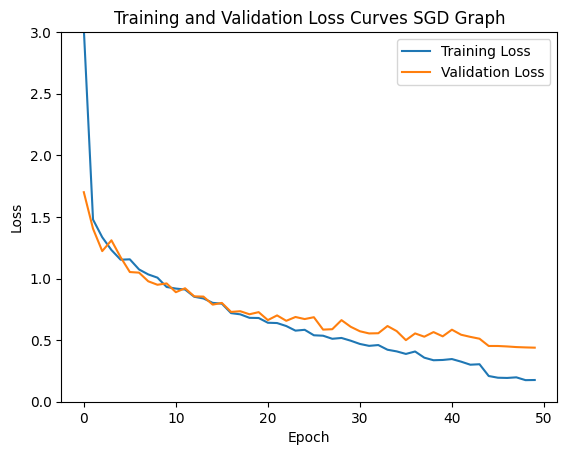

In [4]:
# Train and Test of Architecture Two using *un-weighted* Cross-Entropy Loss function

# Model Instance
model_one_a = ArchitectureThree().to(device)
model_one_b = ArchitectureThree().to(device)

# Epochs
num_epochs = 50

# Optimizer
adamOptimizer = optim.Adam(model_one_a.parameters(), lr=0.00005, weight_decay=0.5)
sdgOptimizer = optim.SGD(model_one_b.parameters(), lr=0.001, momentum=0.93, weight_decay=0.01)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Learning Rate Scheduler
adam_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(adamOptimizer, mode='min', factor=0.1, patience=7)
sdg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(sdgOptimizer, mode='min', factor=0.1, patience=7)

(unweighted_train_losses_a, unweighted_val_losses_a, unweighted_train_accuracy_a, unweighted_val_accuracy_a, 
 unweighted_train_losses_b, unweighted_val_losses_b, unweighted_train_accuracy_b, unweighted_val_accuracy_b) = train(model_one_a, model_one_b, device, train_loader, val_loader, 
                                                                                                                        adamOptimizer, sdgOptimizer, adam_scheduler, sdg_scheduler, num_epochs, criterion, 
                                                                                                                        'Custom All/Architecture Three/Unweighted Architecture Three Adam.pth', 
                                                                                                                        'Custom All/Architecture Three/Unweighted Architecture Three SGD.pth')

a_y_true, a_y_pred, a_y_score = test(model_one_a, device, criterion, test_loader, split='Test Adam')
b_y_true, b_y_pred, b_y_score = test(model_one_b, device, criterion, test_loader, split='Test SGD')

# Print metrics a
lossPlot(unweighted_train_losses_a, unweighted_val_losses_a, 'Adam Graph')

# Print metrics b
lossPlot(unweighted_train_losses_b, unweighted_val_losses_b, 'SGD Graph')


{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


100%|██████████| 203/203 [00:08<00:00, 24.17it/s]


Adam
Epoch 1/50, Training Loss: 2.7153, Validation Loss: 1.5821
Epoch 1/50, Training Acc: 31.893130815544605, Validation Accuracy: 41.105769230769226
SGD
Epoch 1/50, Training Loss: 2.2644, Validation Loss: 1.5189
Epoch 1/50, Training Acc: 30.514504652435686, Validation Accuracy: 44.47115384615385


100%|██████████| 203/203 [00:08<00:00, 24.15it/s]


Adam
Epoch 2/50, Training Loss: 1.6994, Validation Loss: 1.3951
Epoch 2/50, Training Acc: 48.54953475643131, Validation Accuracy: 44.71153846153847
SGD
Epoch 2/50, Training Loss: 1.4674, Validation Loss: 1.3110
Epoch 2/50, Training Acc: 49.68185550082102, Validation Accuracy: 54.32692307692307


...

Adam
Epoch 48/50, Training Loss: 0.8272, Validation Loss: 0.8200
Epoch 48/50, Training Acc: 73.96004378762998, Validation Accuracy: 74.03846153846155
SGD
Epoch 48/50, Training Loss: 0.4558, Validation Loss: 0.6971
Epoch 48/50, Training Acc: 83.48043240284619, Validation Accuracy: 75.24038461538461


100%|██████████| 203/203 [00:08<00:00, 23.95it/s]


Adam
Epoch 49/50, Training Loss: 0.8312, Validation Loss: 0.7896
Epoch 49/50, Training Acc: 73.4434865900383, Validation Accuracy: 76.92307692307693
SGD
Epoch 49/50, Training Loss: 0.4620, Validation Loss: 0.6630
Epoch 49/50, Training Acc: 83.49411603721948, Validation Accuracy: 76.20192307692307


100%|██████████| 203/203 [00:08<00:00, 24.03it/s]


Adam
Epoch 50/50, Training Loss: 0.8219, Validation Loss: 0.8317
Epoch 50/50, Training Acc: 73.06718664477285, Validation Accuracy: 73.07692307692307
SGD
Epoch 50/50, Training Loss: 0.4506, Validation Loss: 0.7473
Epoch 50/50, Training Acc: 83.5727969348659, Validation Accuracy: 73.07692307692307
Models saved successfully!
Test Adam Loss: 0.8431, Test Adam Accuracy: 67.89%
Test SGD Loss: 0.8676, Test SGD Accuracy: 72.06%


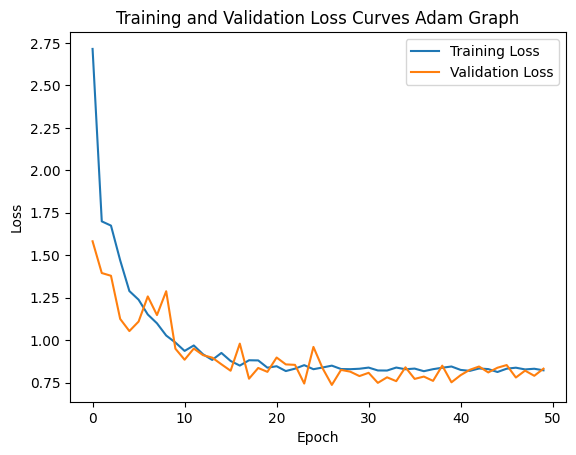

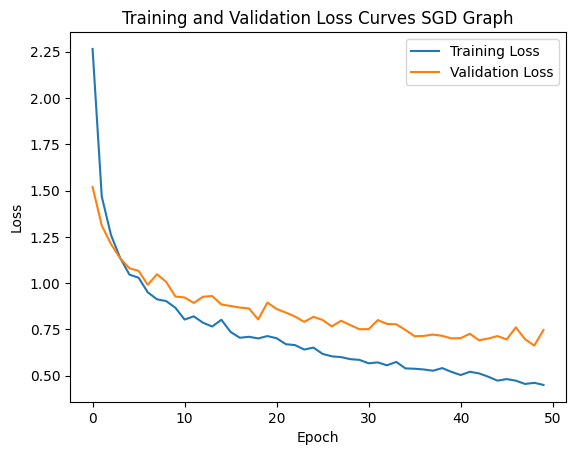

In [7]:
# Train and Test of ArchitectureOne using *weighted* Cross-Entropy Loss function
# Model Instance
model_one_weighted_a = ArchitectureThree().to(device)
model_one_weighted_b = ArchitectureThree().to(device)

# Epochs
num_epochs = 50

# Optimizer
weighted_adamOptimizer = optim.Adam(model_one_weighted_a.parameters(), lr=0.00005, weight_decay=0.5)
weighted_sgdOptimizer = optim.SGD(model_one_weighted_b.parameters(), lr=0.0001, momentum=0.93, weight_decay=0.01)

# Loss Function
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))

# Learning Rate Scheduler
# Learning Rate Scheduler
adam_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(adamOptimizer, mode='min', factor=0.1, patience=7)
sdg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(sdgOptimizer, mode='min', factor=0.1, patience=7)

(weighted_train_losses_a, weighted_val_losses_a, weighted_train_accuracy_a, weighted_val_accuracy_a, 
 weighted_train_losses_b, weighted_val_losses_b, weighted_train_accuracy_b, weighted_val_accuracy_b) = train(model_one_weighted_a, model_one_weighted_b, device, train_loader, val_loader, 
                                                                                                                    weighted_adamOptimizer, weighted_sgdOptimizer, lr_scheduler_a= adam_scheduler, lr_scheduler_b=sdg_scheduler, 
                                                                                                                    num_epochs=num_epochs, criterion=criterion, 
                                                                                                                    name_a= 'Custom All/Architecture Three/Weighted Architecture Three Adam.pth', 
                                                                                                                    name_b= 'Custom All/Architecture Three/Weighted Architecture Three SGD.pth')

a_y_true, a_y_pred, a_y_score = test(model_one_weighted_a, device, criterion, test_loader, split='Test Adam')
b_y_true, b_y_pred, b_y_score = test(model_one_weighted_b, device, criterion, test_loader, split='Test SGD')

# Print metrics a
lossPlot(weighted_train_losses_a, weighted_val_losses_a, 'Adam Graph')

# Print metrics b
lossPlot(weighted_train_losses_b, weighted_val_losses_b, 'SGD Graph')


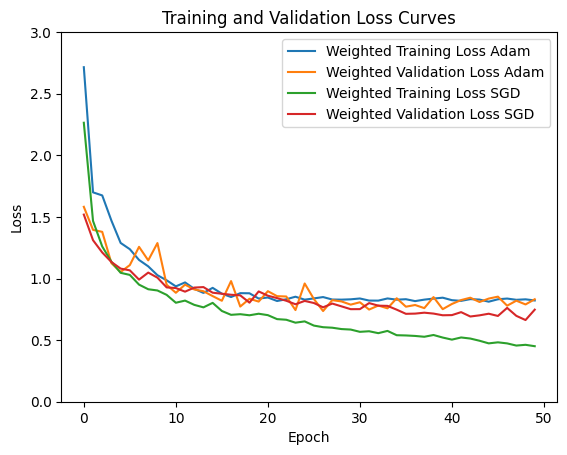

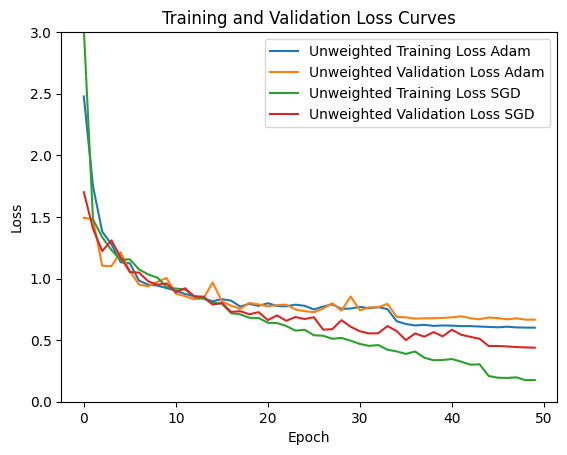

Adam unweighted Split Loss: 0.6866, Adam unweighted Split Accuracy: 77.45%
SGD unweighted Split Loss: 0.6454, SGD unweighted Split Accuracy: 79.66%
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Adam weighted Split Loss: 0.8431, Adam weighted Split Accuracy: 67.89%
SGD weighted Split Loss: 0.8676, SGD weighted Split Accuracy: 72.06%
Fin


In [10]:
def lossPlotUnWeighted():
    # if any(x > 3 for x in unweighted_train_losses_a or unweighted_train_losses_b) or any(x > 3 for x in unweighted_val_losses_a or unweighted_val_losses_b) :
    plt.ylim(0,3)
    plt.plot(unweighted_train_losses_a, label='Unweighted Training Loss Adam')
    plt.plot(unweighted_val_losses_a, label='Unweighted Validation Loss Adam')

    plt.plot(unweighted_train_losses_b, label='Unweighted Training Loss SGD')
    plt.plot(unweighted_val_losses_b, label='Unweighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():
    # if any(x > 3 for x in weighted_train_losses_a) or any(x > 3 for x in weighted_val_losses_a) :
    plt.ylim(0,3)
    plt.plot(weighted_train_losses_a, label='Weighted Training Loss Adam')
    plt.plot(weighted_val_losses_a, label='Weighted Validation Loss Adam')

    plt.plot(weighted_train_losses_b, label='Weighted Training Loss SGD')
    plt.plot(weighted_val_losses_b, label='Weighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

criterion = nn.CrossEntropyLoss()
test(model_one_a, device, criterion, test_loader, 'Adam unweighted Split')
test(model_one_b, device, criterion, test_loader, 'SGD unweighted Split')

criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
test(model_one_weighted_a, device, criterion, test_loader, 'Adam weighted Split')
test(model_one_weighted_b, device, criterion, test_loader, 'SGD weighted Split')

print('Fin')

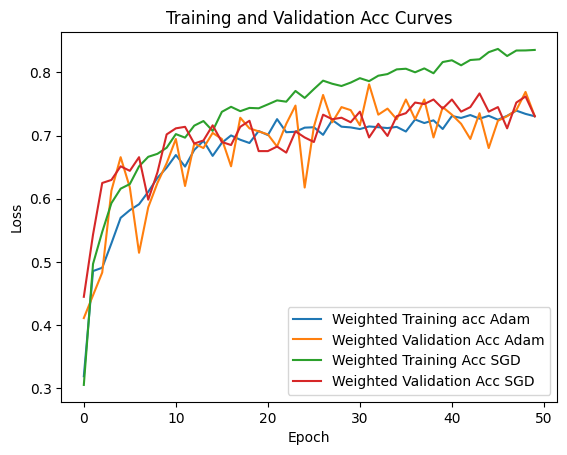

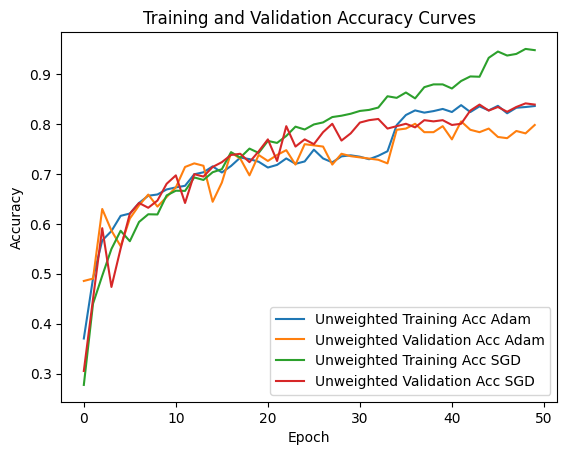

In [11]:
def lossPlotUnWeighted():
    # if any(x > 3 for x in unweighted_train_losses_a or unweighted_train_losses_b) or any(x > 3 for x in unweighted_val_losses_a or unweighted_val_losses_b) :
    plt.plot(unweighted_train_accuracy_a, label='Unweighted Training Acc Adam')
    plt.plot(unweighted_val_accuracy_a, label='Unweighted Validation Acc Adam')

    plt.plot(unweighted_train_accuracy_b, label='Unweighted Training Acc SGD')
    plt.plot(unweighted_val_accuracy_b, label='Unweighted Validation Acc SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():
    # if any(x > 3 for x in weighted_train_losses_a) or any(x > 3 for x in weighted_val_losses_a) :

    plt.plot(weighted_train_accuracy_a, label='Weighted Training acc Adam')
    plt.plot(weighted_val_accuracy_a, label='Weighted Validation Acc Adam')

    plt.plot(weighted_train_accuracy_b, label='Weighted Training Acc SGD')
    plt.plot(weighted_val_accuracy_b, label='Weighted Validation Acc SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Acc Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3280959/3101063449.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Three/Unweighted Architectu

Unweighted Adam Test Loss: 0.6866, Unweighted Adam Test Accuracy: 77.45%
              precision    recall  f1-score   support

       Anger     0.7111    0.6400    0.6737        50
     Disgust     0.8409    0.7255    0.7789        51
        Fear     0.7500    0.3750    0.5000        48
   Happiness     0.8750    0.9423    0.9074        52
     Sadness     0.6531    0.6667    0.6598        48
    Surprise     0.6944    0.9259    0.7937        54
     Neurtal     0.8305    0.9333    0.8789       105

    accuracy                         0.7745       408
   macro avg     0.7650    0.7441    0.7418       408
weighted avg     0.7745    0.7745    0.7633       408



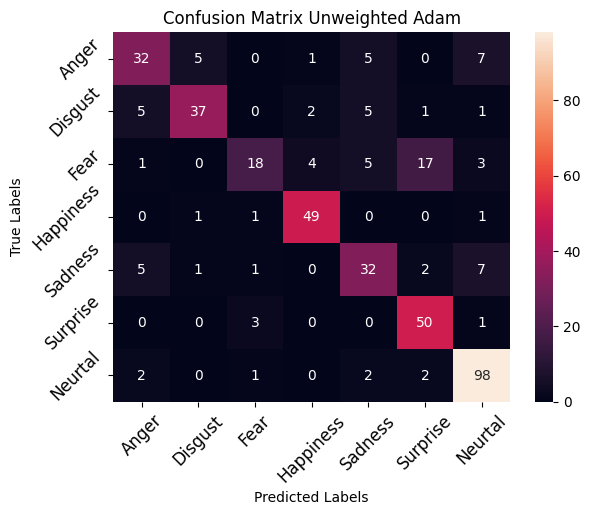

In [16]:
myModel = ArchitectureThree()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Three/Unweighted Architecture Three Adam.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss()
a_unweighted_y_true, a_unweighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted Adam Test')
confusionMatrixPlot(y_true=a_unweighted_y_true, y_pred=a_unweighted_y_pred, title= 'Unweighted Adam')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3280959/131094018.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Three/Unweighted Architectur

Unweighted SGD Test Loss: 0.6454, Unweighted SGD Test Accuracy: 79.66%
              precision    recall  f1-score   support

       Anger     0.7500    0.7200    0.7347        50
     Disgust     0.8409    0.7255    0.7789        51
        Fear     0.6829    0.5833    0.6292        48
   Happiness     0.9231    0.9231    0.9231        52
     Sadness     0.6327    0.6458    0.6392        48
    Surprise     0.7692    0.9259    0.8403        54
     Neurtal     0.8716    0.9048    0.8879       105

    accuracy                         0.7966       408
   macro avg     0.7815    0.7755    0.7762       408
weighted avg     0.7956    0.7966    0.7940       408



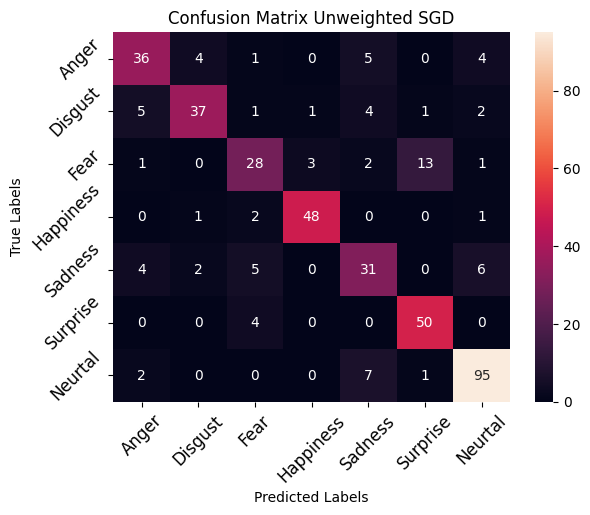

In [17]:
myModel = ArchitectureThree()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Three/Unweighted Architecture Three SGD.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss()
b_unweighted_y_true, b_unweighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted SGD Test')
confusionMatrixPlot(y_true=b_unweighted_y_true, y_pred=b_unweighted_y_pred, title= 'Unweighted SGD')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3280959/3315033552.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Three/Weighted Architecture

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Weighted Adam Test Loss: 0.8431, Weighted Adam Test Accuracy: 67.89%
              precision    recall  f1-score   support

       Anger     0.5962    0.6200    0.6078        50
     Disgust     0.8214    0.4510    0.5823        51
        Fear     0.5000    0.5625    0.5294        48
   Happiness     0.7869    0.9231    0.8496        52
     Sadness     0.4432    0.8125    0.5735        48
    Surprise     0.8333    0.6481    0.7292        54
     Neurtal     0.8916    0.7048    0.7872       105

    accuracy                         0.6789       408
   macro avg     0.6961    0.6746    0.6656       408
weighted avg     0.7267    0.6789    0.6844       408



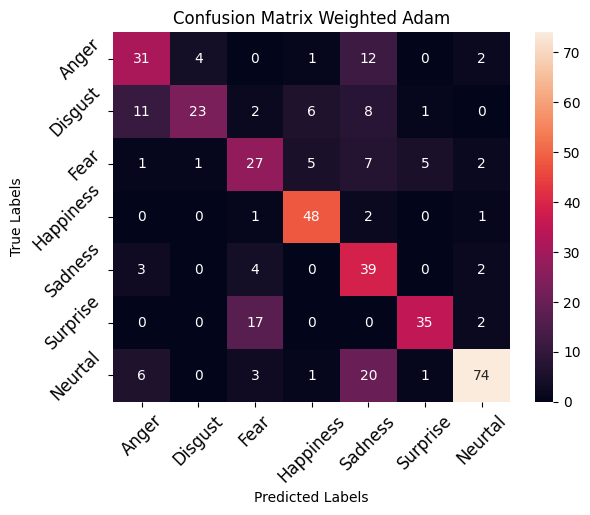

In [18]:
myModel = ArchitectureThree()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Three/Weighted Architecture Three Adam.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
a_weighted_y_true, a_weighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted Adam Test')
confusionMatrixPlot(a_weighted_y_true, a_weighted_y_pred, title= 'Weighted Adam')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3280959/2163898780.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Three/Weighted Architecture

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Weighted SGD Test Loss: 0.8676, Weighted SGD Test Accuracy: 72.06%
              precision    recall  f1-score   support

       Anger     0.5185    0.8400    0.6412        50
     Disgust     0.6964    0.7647    0.7290        51
        Fear     0.5714    0.3333    0.4211        48
   Happiness     0.8475    0.9615    0.9009        52
     Sadness     0.6000    0.4375    0.5060        48
    Surprise     0.7541    0.8519    0.8000        54
     Neurtal     0.9091    0.7619    0.8290       105

    accuracy                         0.7206       408
   macro avg     0.6996    0.7073    0.6896       408
weighted avg     0.7302    0.7206    0.7128       408



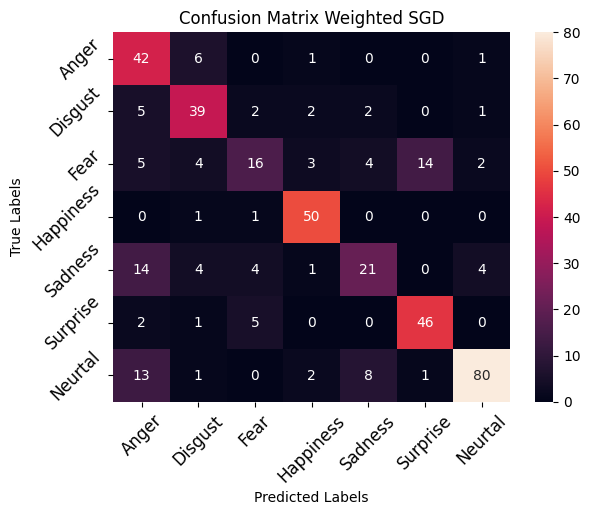

In [19]:
myModel = ArchitectureThree()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Three/Weighted Architecture Three SGD.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
b_weighted_y_true, b_weighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted SGD Test')
confusionMatrixPlot(b_weighted_y_true, b_weighted_y_pred, title= 'Weighted SGD')

**Analysis & Improvements**:

Changes made:
* Decrased Learning Rate to 0.0001 for Adam optimizer, to help with model training
* Further tuned the lr_scheduler for SGD, to help reduce overfitting (decreased patience from 10->7, more frequent updates to lr)
* Add additional convolutional layer
* Implemented Regularization Techniques: increased weight decay from 0.001->0.0001 (added it to SGD), increased momentum to SGD 0.9->0.93

Using figures above (unweighted):
* Adam:
    * Training is more stable, overfits slighlty
* SGD:
    * Training is far more stable

Using figures above (weighted):
* Adam:
    * Training is more stable & less overfitting, decreasing with one another (slight overfitting after 20th epoch)
* SGD:
    * Training is far more stable & lesser overfitting, however begins to overfit alot after 15th epoch


Overall, the training loss and validating loss are beginning to decrease at a similar rate, however issues still occuring:
* Overfitting: the loss curves are divering less from training curves, still occuring but lesser
* Weighted Loss function reduced loss and increased accuracy
